# Práctica: pruebas de hipótesis en microbiomas de fresa
**Material docente para Paula Camila Silva Gomez · Python/Jupyter · 30 septiembre 2026**

Pregunta: ¿el estado de la planta se asocia con la diversidad de su microbioma rizosférico, la abundancia relativa de *Fusarium* o la composición de la comunidad?

Objetivos: formular hipótesis, distinguir preguntas biológicas, analizar datos reproduciblemente y comunicar efectos, incertidumbre y límites. Duración sugerida: dos sesiones de dos horas. Requisitos previos: vectores, proporciones y Python básico.

## Cómo ejecutar en Google Colab
1. Abre https://colab.research.google.com/ y elige **Archivo → Subir notebook**.
2. Sube este `.ipynb`; no necesitas subir los datos.
3. Selecciona **Entorno de ejecución → Ejecutar todo**. Usa CPU; no se requiere GPU.
4. La última celda descarga un ZIP con los resultados.

### Otras opciones
Abre este notebook en JupyterLab, Jupyter Notebook, VS Code o Google Colab y selecciona **Restart Kernel and Run All** (en Colab: Ejecutar todo). Recomendamos Python 3.11 o 3.12. La primera celda instala sólo paquetes ausentes; necesita internet si faltan dependencias. Después puedes trabajar sin conexión.

Los datos están incluidos tanto en `data/` como comprimidos dentro del notebook: **el `.ipynb` funciona por sí solo**. Se guardan tablas y figuras en `resultados/`. Las salidas incluidas corresponden a una ejecución de esta práctica, no a resultados copiados del PDF.

Dependencias: numpy, pandas, scipy, matplotlib, scikit-bio, IPython. JupyterLab e ipykernel son necesarios para ejecutarlo localmente. El archivo `requirements.txt` permite instalarlas con `python -m pip install -r requirements.txt`. Las versiones exactas ejecutadas se registran al final.


In [1]:
import importlib.util, subprocess, sys
paquetes = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy>=1.11",
            "matplotlib": "matplotlib", "skbio": "scikit-bio>=0.6.3", "IPython": "ipython"}
faltan = [pip for modulo, pip in paquetes.items() if importlib.util.find_spec(modulo) is None]
if faltan:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltan])
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import entr
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova, permdisp
from skbio.stats.ordination import pcoa
from IPython.display import display, Markdown
from pathlib import Path
import json, base64, zlib, hashlib, platform, importlib.metadata
SEED = 20260930
B = 9999
ALPHA = 0.05
OUT = Path("resultados")
OUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})
print("Python:", platform.python_version(), "| Permutaciones:", B)


Python: 3.12.14 | Permutaciones: 9999


## 1. ¿Qué es una prueba de hipótesis?
Definimos una hipótesis nula $H_0$, una alternativa $H_1$, un estadístico y una distribución de referencia bajo $H_0$. El **valor p** es la probabilidad, bajo el modelo nulo y sus supuestos, de obtener un estadístico al menos tan extremo como el observado. No es la probabilidad de que la hipótesis nula sea verdadera.

Fijamos $\alpha=0.05$ y alternativas bilaterales antes del cálculo. Un p pequeño permite rechazar $H_0$ bajo los supuestos; un p alto no demuestra igualdad. Significancia estadística no mide importancia biológica ni acredita causalidad.

| Pregunta | Variable | Prueba | Efecto |
|---|---|---|---|
| ¿Difiere la diversidad? | Shannon por muestra | Welch | Diferencia de medias e IC |
| ¿Difiere Fusarium? | Proporción de lecturas | Mann–Whitney | Probabilidad de superioridad |
| ¿Difiere la composición? | Perfiles de géneros | PERMANOVA | $R^2$ y pseudo-F |

**Diseño pendiente de confirmar:** los metadatos sólo incluyen ID y tratamiento. El cálculo supone grupos independientes y permutaciones libres. No conocemos sitio, parcela, planta, fecha, pares ni réplicas técnicas. Antes de usar la inferencia final en la tesis, Camila debe confirmar el diseño. Si hay bloques o pares, se debe modificar el análisis. No inferimos independencia a partir del nombre de la muestra.

**Actividad 1:** escribe tus hipótesis y predicciones antes de ejecutar. ¿Por qué abundancia relativa no equivale a cantidad absoluta?


## 2. Procedencia y carga de datos
Fuente: [Tesis_Maestria de Camila](https://github.com/CamilaSilva1995/Tesis_Maestria), revisión `0edc908ca905fd1ece8132b65f4eebecfe0f2c0a`. Archivos `Data/fresa_solena/Data1/fresa_kraken.biom` y `metadata.csv`.

El BIOM contiene conteos de lecturas clasificadas. No son conteos de células. Se reproducen las cinco exclusiones de la tesis; no se revalida aquí el umbral de calidad de fastp. Se verifican checksums, nombres únicos, grupos y alineación por identificador. BIOM usa índices desde cero, como Python.


In [2]:
# Datos comprimidos incluidos para permitir el uso del notebook sin archivos externos.
EMBEDDED = {'metadata.csv': 'eJxdkr0KwzAMhPc+SwZJjmV57xroKxQaSCFjoPTt+7PEn8bj5NPdycvNxGPa1vt+bO/L8oXRTng16XV6PfdjffzJytneCck6WW/cQ7YK1rpjLT21k/w55ChlG2TVxllV+FURQKXfuUNJ6+ihjo5U4ciFOqlCRFNB3Z2lxEiqpFJAWsoC81KxpaWg1HUEDRRoKFuN0VqwexgsfFp4Cmu8DFnlUQuEZyYvaRaHEhwq0svkIX0swjgdfgDcrgBm', 'fresa_kraken.biom': '...'}
SHA256 = {'metadata.csv': 'a734f59ccf23f1928ac897a8d7d651242a598f1d02735360fcc7344eb3b0907b', 'fresa_kraken.biom': 'e10da3d65b45bece0b298bdb9c77c26c91923ad21df89fe72931fc17a16bdef5'}
DATA = Path("data")
DATA.mkdir(exist_ok=True)
for nombre, contenido in EMBEDDED.items():
    ruta = DATA / nombre
    if not ruta.exists():
        ruta.write_bytes(zlib.decompress(base64.b64decode(contenido)))
    if hashlib.sha256(ruta.read_bytes()).hexdigest() != SHA256[nombre]:
        raise ValueError(f"{nombre} cambió: usa la copia de esta práctica o revisa su procedencia.")
biom = json.loads((DATA / "fresa_kraken.biom").read_text())
assert biom["matrix_type"] == "sparse"
X = np.zeros(biom["shape"], dtype=float)
for i, j, valor in biom["data"]:
    X[i, j] = valor
ids = [c["id"].removesuffix(".kraken2.report") for c in biom["columns"]]
taxon_ids = [r["id"] for r in biom["rows"]]
assert len(set(ids)) == len(ids) and len(set(taxon_ids)) == len(taxon_ids)
tax = pd.DataFrame([[s[3:] for s in r["metadata"]["taxonomy"]] for r in biom["rows"]],
                   columns=["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"],
                   index=taxon_ids)
meta = pd.read_csv(DATA / "metadata.csv", header=None, names=["Sample", "Treatment"])
assert meta.Sample.is_unique and set(meta.Sample) == set(ids)
meta = meta.set_index("Sample").loc[ids]
assert meta.Treatment.isin(["healthy", "wilted"]).all()
excluir = ["MP2079", "MP2080", "MP2088", "MP2109", "MP2137"]
assert set(excluir).issubset(meta.index)
keep = ~meta.index.isin(excluir)
X, meta = X[:, keep], meta.loc[keep].copy()
meta["Grupo"] = meta.Treatment.map({"healthy": "Sana", "wilted": "Marchita"})
assert np.isfinite(X).all() and (X >= 0).all() and (X.sum(axis=0) > 0).all()
assert meta.Grupo.value_counts().to_dict() == {"Sana": 35, "Marchita": 18}
meta["Lecturas_clasificadas"] = X.sum(axis=0)
healthy = meta.Grupo.to_numpy() == "Sana"
groups = meta.Grupo.to_numpy()
display(meta.groupby("Grupo").agg(n=("Grupo", "size"),
                                  mediana_lecturas=("Lecturas_clasificadas", "median")))
print("Matriz taxones × muestras:", X.shape)
meta.to_csv(OUT / "metadatos_utilizados.csv")


Matriz taxones × muestras: (9003, 53)


,n,mediana_lecturas
Grupo,,
Marchita,18,12051589.0
Sana,35,12146967.0


**Actividad 2:** ¿qué pasaría si se unieran metadatos y abundancias por posición en vez de ID? En el script de la figura 4.13 hay una corrección posterior al PDF para esta alineación; aquí recalculamos los valores.

### Visualizar profundidad y datos individuales
Las proporciones corrigen la escala del total, pero no todos los sesgos de detección. La profundidad de lecturas clasificadas no es necesariamente el total del FASTQ. No rarefactamos en esta práctica; si la profundidad se asocia al grupo, conviene un análisis de sensibilidad adicional.


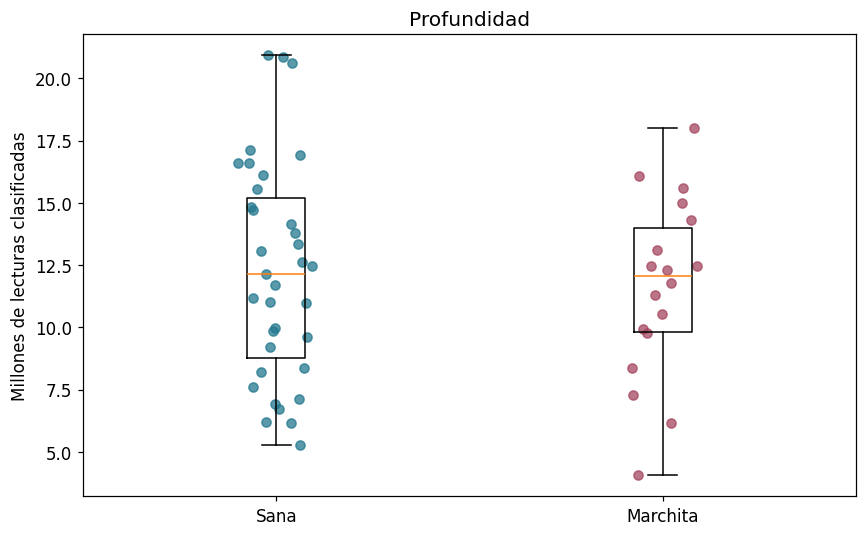

In [3]:
def plot_groups(values, ylabel, title, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    values = np.asarray(values)
    arrays = [values[healthy], values[~healthy]]
    ax.boxplot(arrays, labels=["Sana", "Marchita"], showfliers=False)
    rng = np.random.default_rng(SEED)
    for i, (arr, color) in enumerate(zip(arrays, ["#24788e", "#a54760"]), 1):
        ax.scatter(i + rng.uniform(-0.10, 0.10, len(arr)), arr, color=color, alpha=.75)
    ax.set(ylabel=ylabel, title=title)
    return ax
plot_groups(meta.Lecturas_clasificadas / 1e6, "Millones de lecturas clasificadas", "Profundidad")
plt.tight_layout(); plt.show()


## 3. Diversidad alfa: Shannon
$H=-\sum_j p_j\log p_j$, con logaritmo natural y $0\log0=0$. Resume riqueza y equidad; no identifica los taxones. Dos comunidades diferentes pueden tener igual Shannon.

Calculamos Shannon de (a) filas originales del BIOM, cuya resolución no equivale automáticamente a especies; y (b) géneros de eucariotas identificados, agregando conteos y descartando géneros vacíos. Mostramos la fracción descartada. Este segundo criterio reproduce la selección de géneros identificados del script original.


Géneros de eucariotas: 58


,Shannon_tabla,Shannon_eucariotas,Fraccion_euk_sin_genero
Grupo,,,
Marchita,7.417243,3.034570,0.021617
Sana,7.478431,3.076716,0.022084


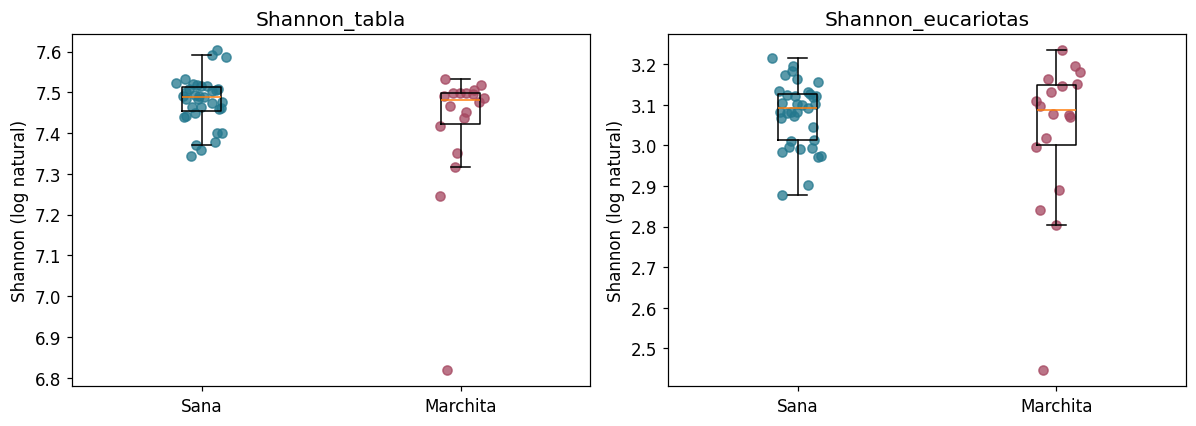

In [4]:
genus = tax.Genus.fillna("").str.strip().to_numpy()
euk = tax.Kingdom.to_numpy() == "Eukaryota"
valid = ~np.isin(genus, ["", "NA", "NaN"])
euk_valid = euk & valid
# Agregar filas por género, manteniendo las columnas alineadas con meta.
euk_gen = pd.DataFrame(X[euk_valid], index=genus[euk_valid], columns=meta.index).groupby(level=0).sum()
euk_gen = euk_gen.loc[euk_gen.sum(axis=1) > 0]
assert (euk_gen.sum(axis=0) > 0).all()
def shannon(counts):
    counts = np.asarray(counts, dtype=float)
    return entr(counts / counts.sum(axis=0)).sum(axis=0)
meta["Shannon_tabla"] = shannon(X)
meta["Shannon_eucariotas"] = shannon(euk_gen.to_numpy())
meta["Fraccion_euk_sin_genero"] = 1 - euk_gen.sum(axis=0).to_numpy() / X[euk].sum(axis=0)
print("Géneros de eucariotas:", len(euk_gen))
display(meta.groupby("Grupo")[["Shannon_tabla", "Shannon_eucariotas", "Fraccion_euk_sin_genero"]].mean())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ["Shannon_tabla", "Shannon_eucariotas"]):
    plot_groups(meta[name], "Shannon (log natural)", name, ax)
plt.tight_layout(); plt.show()


### Welch: diferencia de medias
$H_0:\mu_s=\mu_m$ frente a $H_1:\mu_s\ne\mu_m$. El estadístico es $t=(\bar x-\bar y)/\sqrt{s_x^2/n_x+s_y^2/n_y}$. Welch permite varianzas diferentes, pero requiere independencia y una aproximación razonable para la distribución de las medias. Revisamos extremos y asimetría con gráficos Q–Q, sin usar un pretest automático para elegir la prueba.

Reportamos diferencia de medias (sana menos marchita), IC individual del 95 %, grados de libertad y p. Aplicamos Holm a la familia de dos contrastes de alfa. El ajuste no modifica estos IC individuales: no son intervalos simultáneos.


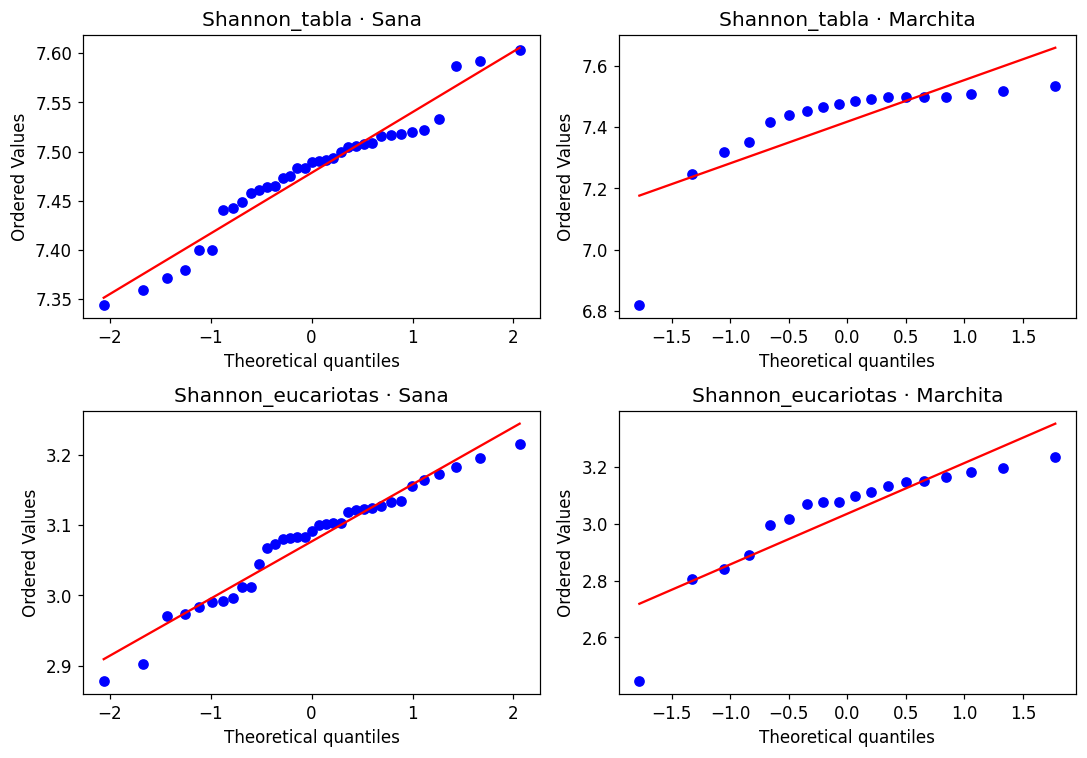

,Variable,Media_sana,Media_marchita,Diferencia,IC95_inf,IC95_sup,t,gl,p,p_Holm_alfa
0,Shannon_tabla,7.478431,7.417243,0.061188,-0.024156,0.146532,1.498776,19.348072,0.150071,0.300143
1,Shannon_eucariotas,3.076716,3.034570,0.042146,-0.055264,0.139557,0.902008,20.180343,0.377693,0.377693


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, variable in enumerate(["Shannon_tabla", "Shannon_eucariotas"]):
    for col, mask in enumerate([healthy, ~healthy]):
        stats.probplot(meta[variable].to_numpy()[mask], dist="norm", plot=axes[row, col])
        axes[row, col].set_title(variable + (" · Sana" if col == 0 else " · Marchita"))
plt.tight_layout(); plt.show()
def holm(pvalues):
    p = np.asarray(pvalues)
    order = np.argsort(p)
    adjusted_sorted = np.minimum(1, np.maximum.accumulate(p[order] * (len(p) - np.arange(len(p)))))
    result = np.empty_like(p)
    result[order] = adjusted_sorted
    return result
rows = []
for variable in ["Shannon_tabla", "Shannon_eucariotas"]:
    x, y = meta[variable].to_numpy()[healthy], meta[variable].to_numpy()[~healthy]
    result = stats.ttest_ind(x, y, equal_var=False, alternative="two-sided")
    vx, vy = x.var(ddof=1)/len(x), y.var(ddof=1)/len(y)
    df = (vx + vy)**2 / (vx**2/(len(x)-1) + vy**2/(len(y)-1))
    delta, margin = x.mean()-y.mean(), stats.t.ppf(.975, df)*np.sqrt(vx+vy)
    rows.append(dict(Variable=variable, Media_sana=x.mean(), Media_marchita=y.mean(),
                     Diferencia=delta, IC95_inf=delta-margin, IC95_sup=delta+margin,
                     t=result.statistic, gl=df, p=result.pvalue))
alpha_results = pd.DataFrame(rows)
alpha_results["p_Holm_alfa"] = holm(alpha_results.p)
display(alpha_results)
alpha_results.to_csv(OUT / "welch_shannon.csv", index=False)


**Actividad 3:** escribe un párrafo con dirección, diferencia, IC y p ajustado. Si el IC incluye cero, ¿qué concluyes? Compara el Shannon de eucariotas con el PDF: la práctica usa la asignación corregida por ID.

Una prueba t con varianzas iguales o Mann–Whitney puede mostrarse como comparación docente, pero no se deben probar alternativas hasta encontrar un p significativo. Tampoco son replicaciones independientes del mismo hallazgo.


## 4. Fusarium: abundancia relativa y rangos
Sumamos todas las filas asignadas al género. El análisis principal divide entre todas las lecturas clasificadas; la sensibilidad divide entre las lecturas de eucariotas. El denominador cambia la pregunta.

Mann–Whitney es Wilcoxon de **suma de rangos**, para grupos independientes. No es Wilcoxon de rangos con signo para datos pareados. $H_0$: misma distribución entre grupos; $H_1$: diferencia. Su interpretación como diferencia de localización/medianas requiere supuestos adicionales sobre las formas; no compara las medias. Usamos aproximación asintótica, bilateral y corrección por continuidad.

Efecto: $A=P(X_s>X_m)+\tfrac12P(X_s=X_m)$ estimado con todos los pares. $A=0.5$ representa ausencia de dominancia por rangos; $2A-1$ va de -1 a 1. Un valor positivo favorece abundancias más altas en sanas.


,Denominador,Mediana_sana_pct,Mediana_marchita_pct,U,p,A_sana_mayor,Efecto_rangos
0,Fusarium_total,0.119418,0.126679,317.0,0.977525,0.503175,0.006349
1,Fusarium_euk,19.576135,19.178323,323.0,0.887981,0.512698,0.025397


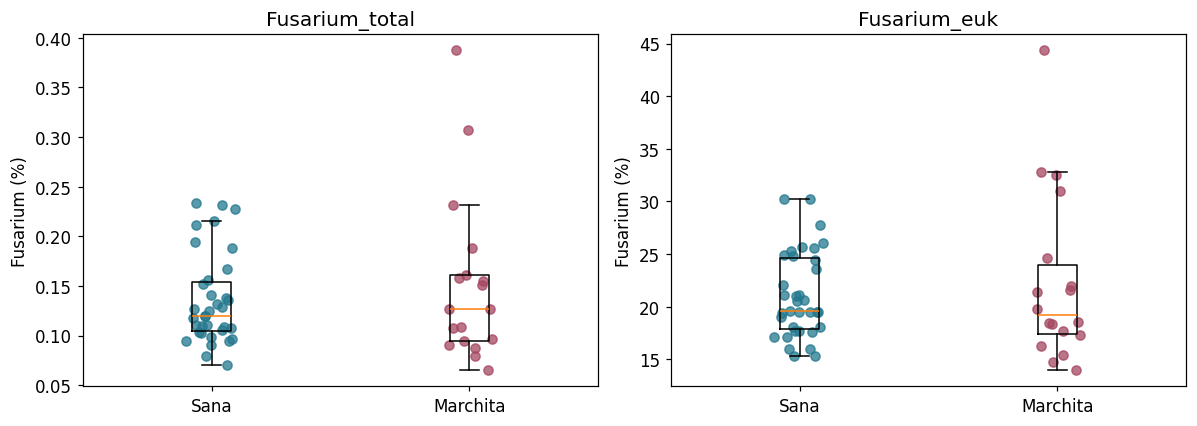

,Efecto,IC95_inf,IC95_sup
0,0.006349,-0.361905,0.368254


In [6]:
fus = genus == "Fusarium"
assert fus.any()
meta["Fusarium_lecturas"] = X[fus].sum(axis=0)
meta["Fusarium_total"] = X[fus].sum(axis=0) / X.sum(axis=0)
meta["Fusarium_euk"] = X[fus].sum(axis=0) / X[euk].sum(axis=0)
def superiority(x, y):
    diff = np.asarray(x)[:, None] - np.asarray(y)[None, :]
    return (diff > 0).mean() + .5 * (diff == 0).mean()
rows = []
for variable in ["Fusarium_total", "Fusarium_euk"]:
    x, y = meta[variable].to_numpy()[healthy], meta[variable].to_numpy()[~healthy]
    r = stats.mannwhitneyu(x, y, alternative="two-sided", method="asymptotic", use_continuity=True)
    A = superiority(x, y)
    rows.append(dict(Denominador=variable, Mediana_sana_pct=100*np.median(x),
                     Mediana_marchita_pct=100*np.median(y), U=r.statistic, p=r.pvalue,
                     A_sana_mayor=A, Efecto_rangos=2*A-1))
fus_results = pd.DataFrame(rows)
display(fus_results)
fus_results.to_csv(OUT / "fusarium_mann_whitney.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, variable in zip(axes, ["Fusarium_total", "Fusarium_euk"]):
    plot_groups(100*meta[variable], "Fusarium (%)", variable, ax)
plt.tight_layout(); plt.savefig(OUT / "fusarium.png", dpi=300); plt.show()
x, y = meta.Fusarium_total.to_numpy()[healthy], meta.Fusarium_total.to_numpy()[~healthy]
rng = np.random.default_rng(SEED)
boot = np.array([2*superiority(rng.choice(x, len(x), replace=True),
                             rng.choice(y, len(y), replace=True))-1 for _ in range(2000)])
ci = np.quantile(boot, [.025, .975])
effect_fus = pd.DataFrame([dict(Efecto=2*superiority(x,y)-1, IC95_inf=ci[0], IC95_sup=ci[1])])
display(effect_fus)
effect_fus.to_csv(OUT / "fusarium_efecto_bootstrap.csv", index=False)


El IC bootstrap percentil es aproximado, remuestrea dentro de cada grupo y supone independencia. *Fusarium* fue señalado durante la exploración original: esto no es validación independiente. No seleccionamos el menor p de los dos denominadores. Si ambos se usaran para declarar hallazgos, correspondería ajustar esa multiplicidad; si se prueban muchos géneros, se necesitan una estrategia de múltiples comparaciones y métodos apropiados para composición.

**Actividad 4:** ¿un p alto demuestra irrelevancia de Fusarium para la enfermedad? ¿Qué impide reconocer cepas patógenas con lecturas asignadas al género? ¿Puede la proporción disminuir aunque la cantidad de células aumente?


## 5. Composición comunitaria: PERMANOVA
Agregamos géneros identificados por reino y género. Excluimos géneros vacíos y mostramos qué fracción de lecturas se descarta. Después renormalizamos. La comunidad original y este subconjunto responden preguntas de resolución diferentes.

Bray–Curtis: $d(x,y)=\sum_j|x_j-y_j|/\sum_j(x_j+y_j)$. PERMANOVA contrasta el efecto del grupo en esta geometría mediante pseudo-F y permutación de etiquetas; $R^2$ es la fracción de variación atribuida al grupo en el modelo de un factor. Usamos 9999 permutaciones libres y semilla fija. El p se calcula con corrección $(b+1)/(B+1)$.

$H_0$: ausencia de efecto del grupo bajo el diseño de permutación. No presupone normalidad multivariante, pero **sí requiere un diseño intercambiable**. Puede responder a cambios de dispersión además de localización, especialmente con grupos desiguales. Es distinta de comparar Shannon o Fusarium.


In [7]:
keys = tax.Kingdom.to_numpy()[valid] + ":" + genus[valid]
genera = pd.DataFrame(X[valid], index=keys, columns=meta.index).groupby(level=0).sum()
genera = genera.loc[genera.sum(axis=1) > 0]
meta["Fraccion_sin_genero"] = 1-genera.sum(axis=0).to_numpy()/X.sum(axis=0)
community = genera.T
assert community.index.equals(meta.index) and (community.sum(axis=1) > 0).all()
relative = community.div(community.sum(axis=1), axis=0)
assert np.allclose(relative.sum(axis=1), 1)
display(meta.groupby("Grupo")["Fraccion_sin_genero"].agg(["median", "min", "max"]))
D = squareform(pdist(relative.to_numpy(), metric="braycurtis"))
dm = DistanceMatrix(D, ids=list(meta.index))
# Semilla fija y un factor: las etiquetas están en el mismo orden que dm.
perma = permanova(dm, groups, permutations=B, seed=SEED)
F = float(perma["test statistic"])
n, g = len(groups), len(np.unique(groups))
R2 = (g-1)*F / ((g-1)*F+n-g)
perma_table = pd.DataFrame([dict(n=n, grupos=g, pseudo_F=F, R2=R2,
                               p=float(perma["p-value"]), permutaciones=B)])
display(perma_table)
perma_table.to_csv(OUT / "permanova_bray_curtis.csv", index=False)
# Comprobación independiente del estadístico mediante sumas de cuadrados.
ss_total = np.sum(D**2)/(2*n)
ss_within = sum(np.sum(D[np.ix_(groups==label, groups==label)]**2)/(2*np.sum(groups==label))
                for label in np.unique(groups))
F_direct = ((ss_total-ss_within)/(g-1))/(ss_within/(n-g))
assert np.isclose(F, F_direct), (F, F_direct)
assert np.isclose(R2, (ss_total-ss_within)/ss_total)


,median,min,max
Grupo,,,
Marchita,0.056047,0.050494,0.063742
Sana,0.057551,0.049042,0.066052


,n,grupos,pseudo_F,R2,p,permutaciones
0,53,2,1.142231,0.021906,0.3007,9999


### PERMDISP: diagnóstico de dispersión
PERMDISP compara las distancias a la mediana espacial de cada grupo. Para este diagnóstico usamos **raíz cuadrada de Bray–Curtis** y PCoA completa (`eigh`), mientras que la PERMANOVA principal usa Bray–Curtis sin transformar. Se declara esa diferencia.

La implementación de scikit-bio no expone la corrección `bias.adjust=True` de vegan usada en la versión R: por tanto, este diagnóstico no se presenta como una reproducción numérica exacta de aquel. Reportamos la implementación y los tamaños 35/18. La mediana espacial no es la mediana calculada por separado en cada coordenada.


In [8]:
sqrt_dm = DistanceMatrix(np.sqrt(D), ids=list(meta.index))
disp = permdisp(sqrt_dm, groups, test="median", method="eigh", permutations=B, seed=SEED)
disp_table = pd.DataFrame([dict(F=float(disp["test statistic"]), p=float(disp["p-value"]),
                              permutaciones=B, centro="mediana espacial",
                              distancia="raíz de Bray–Curtis", correccion_tamano=False)])
display(disp_table)
disp_table.to_csv(OUT / "permdisp.csv", index=False)


,F,p,permutaciones,centro,distancia,correccion_tamano
0,3.01261,0.0821,9999,mediana espacial,raíz de Bray–Curtis,False


Si PERMANOVA y PERMDISP son significativas, no atribuyas el resultado automáticamente a un desplazamiento de los centros. Un p alto de PERMDISP tampoco demuestra dispersión idéntica. Reporta ambos p, $R^2$, pseudo-F, tamaños y permutaciones.

### PCoA: ayuda visual
La ordenación usa raíz de Bray–Curtis. Se inspeccionan los autovalores; scikit-bio avisa si aparecen autovalores negativos relevantes. Sólo las primeras dos dimensiones se muestran; el gráfico no sustituye la prueba. Esta geometría difiere de la PERMANOVA sin transformar.


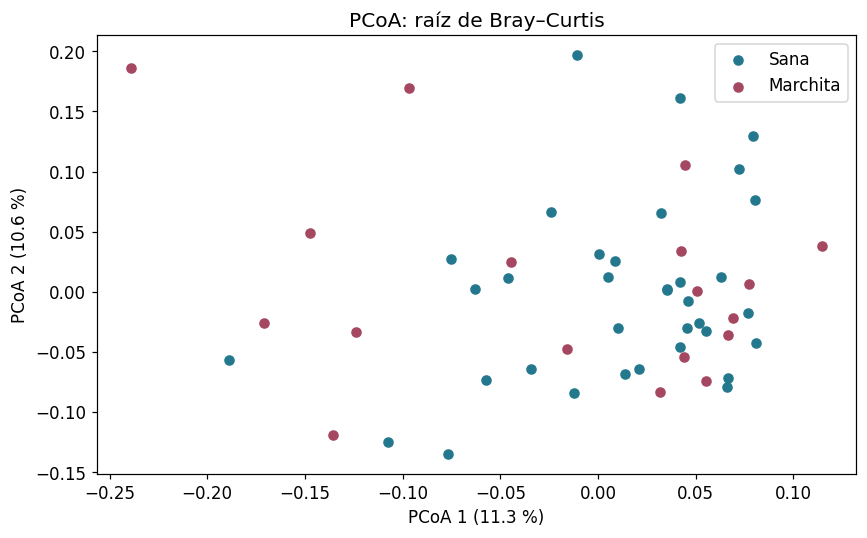

/root/.local/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:259: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


In [9]:
ordination = pcoa(sqrt_dm, method="eigh")
coords = ordination.samples.iloc[:, :2].copy()
coords.columns = ["PCoA1", "PCoA2"]
coords["Grupo"] = meta.loc[coords.index, "Grupo"]
fig, ax = plt.subplots()
for label, color in [("Sana", "#24788e"), ("Marchita", "#a54760")]:
    c = coords.loc[coords.Grupo == label]
    ax.scatter(c.PCoA1, c.PCoA2, label=label, color=color, s=35)
percent = ordination.proportion_explained.iloc[:2].to_numpy()*100
ax.set(xlabel=f"PCoA 1 ({percent[0]:.1f} %)", ylabel=f"PCoA 2 ({percent[1]:.1f} %)",
       title="PCoA: raíz de Bray–Curtis")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "pcoa.png", dpi=300); plt.show()
coords.to_csv(OUT / "pcoa_coordenadas.csv")


**Actividad 5:** compara p y $R^2$. ¿Un efecto significativo implica clasificación precisa de plantas individuales? ¿Qué cambiarías si varias muestras procedieran de una misma parcela?

### Si existen bloques, pares o covariables
Este notebook ejecuta un modelo de un factor con permutaciones libres. `scikit-bio.permanova` no equivale a una fórmula multifactorial con covariables y `strata` de vegan. Si hay estructura de sitio/parcela, incorpora metadatos reales y utiliza una implementación adecuada al diseño, por ejemplo `vegan::adonis2` con permutaciones restringidas. No inventes bloques ni ajustes el diseño para obtener significancia. Si salud está confundida con sitio, no se identifica un efecto independiente de salud con estos datos.


## 6. Cierre, multiplicidad y comunicación
Definimos una familia docente de cuatro contrastes principales: los dos Shannon, Fusarium respecto al total clasificado y composición. Mostramos Holm sobre esta familia, además de los p sin ajustar. PERMDISP es un diagnóstico. La sensibilidad de Fusarium no es otra oportunidad de declarar un hallazgo. La familia real debe definirse por las preguntas científicas que se usarán para concluir; el ajuste no transforma una exploración en confirmación.


In [10]:
summary = pd.DataFrame({
    "Pregunta": ["Shannon tabla original", "Shannon géneros eucariotas", "Fusarium total", "Composición géneros"],
    "Prueba": ["Welch", "Welch", "Mann–Whitney", "PERMANOVA"],
    "p": [*alpha_results.p, fus_results.p.iloc[0], perma_table.p.iloc[0]]})
summary["p_Holm_cuatro"] = holm(summary.p)
summary["Decision"] = np.where(summary.p_Holm_cuatro < ALPHA, "Rechazar H0", "No rechazar H0")
display(summary)
summary.to_csv(OUT / "resumen_pruebas.csv", index=False)
meta.to_csv(OUT / "variables_por_muestra.csv")
community.to_csv(OUT / "conteos_generos.csv")
relative.to_csv(OUT / "abundancias_relativas_generos.csv")
display(Markdown(f"**Resultados calculados:** PERMANOVA pseudo-F = {F:.4f}, "
                 f"R² = {R2:.4f}, p = {perma_table.p.iloc[0]:.4f}; "
                 f"PERMDISP p = {disp_table.p.iloc[0]:.4f}. "
                 "Inferencia provisional: diseño e independencia por confirmar."))


,Pregunta,Prueba,p,p_Holm_cuatro,Decision
0,Shannon tabla original,Welch,0.150071,0.600285,No rechazar H0
1,Shannon géneros eucariotas,Welch,0.377693,0.902100,No rechazar H0
2,Fusarium total,Mann–Whitney,0.977525,0.977525,No rechazar H0
3,Composición géneros,PERMANOVA,0.300700,0.902100,No rechazar H0


**Resultados calculados:** PERMANOVA pseudo-F = 1.1422, R² = 0.0219, p = 0.3007; PERMDISP p = 0.0821. Inferencia provisional: diseño e independencia por confirmar.

### Entrega del alumno
Escribe un párrafo por pregunta. Incluye: variable y denominador/resolución, hipótesis, prueba, dirección y tamaño del efecto, incertidumbre disponible, p y ajuste. Para composición agrega dispersión. Termina con tres limitaciones y una propuesta de seguimiento.

No interpretes p alto como equivalencia; no atribuyas patogenicidad a todas las lecturas del género ni asociación como causalidad.

### Guía docente para Camila
Antes del código, pedir predicciones individuales y discutir hipótesis en parejas. Ejecutar bloques y comentar decisiones antes de avanzar. Rúbrica: hipótesis 25 %, reproducibilidad/manejo de datos 25 %, interpretación de efecto e incertidumbre 30 %, limitaciones 20 %. Si se incorpora como anexo de tesis, describir el material y propósito; sólo reportar aprendizaje observado si se impartió y evaluó.

## 7. Versiones, procedencia y referencias
Las semillas de Python y R no producen necesariamente las mismas permutaciones: los p de Monte Carlo pueden variar entre implementaciones. La comprobación independiente de pseudo-F se ejecuta arriba. Welch y Mann–Whitney se contrastaron con la tabla de datos original; no se toman resultados del PDF.


In [11]:
packages = ["numpy", "pandas", "scipy", "matplotlib", "scikit-bio", "ipython"]
versions = {p: importlib.metadata.version(p) for p in packages}
versions["python"] = platform.python_version()
provenance = dict(revision="0edc908ca905fd1ece8132b65f4eebecfe0f2c0a", seed=SEED,
                  permutations=B, excluded=excluir, sha256=SHA256, versions=versions,
                  inference="Independencia y diseño de muestreo pendientes de confirmar")
(OUT / "procedencia.json").write_text(json.dumps(provenance, ensure_ascii=False, indent=2))
display(pd.Series(versions, name="Versión"))
print("Archivos de resultados:", sorted(p.name for p in OUT.iterdir()))


Archivos de resultados: ['abundancias_relativas_generos.csv', 'conteos_generos.csv', 'fusarium.png', 'fusarium_efecto_bootstrap.csv', 'fusarium_mann_whitney.csv', 'metadatos_utilizados.csv', 'pcoa.png', 'pcoa_coordenadas.csv', 'permanova_bray_curtis.csv', 'permdisp.csv', 'procedencia.json', 'resumen_pruebas.csv', 'variables_por_muestra.csv', 'welch_shannon.csv']


numpy           2.3.5
pandas          2.2.3
scipy          1.17.0
matplotlib     3.10.8
scikit-bio      0.7.4
ipython        9.17.1
python        3.12.14
Name: Versión, dtype: object

Referencias y documentación:

- Anderson, M. J. (2001). A new method for non-parametric multivariate analysis of variance. *Austral Ecology*, 26:32–46.
- [scikit-bio: PERMANOVA](https://scikit.bio/docs/latest/generated/skbio.stats.distance.permanova.html).
- [scikit-bio: PERMDISP](https://scikit.bio/docs/latest/generated/skbio.stats.distance.permdisp.html).
- [SciPy: ttest_ind](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).
- [SciPy: mannwhitneyu](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).
- [vegan: PERMANOVA y diseños multifactoriales](https://vegandevs.github.io/vegan/reference/adonis.html).
- [Repositorio fuente](https://github.com/CamilaSilva1995/Tesis_Maestria).


## 8. Descargar resultados en Colab
Esta celda comprime las tablas y figuras. En Colab inicia la descarga; localmente crea el mismo ZIP. Para conservar el notebook editado, usa **Archivo → Descargar → Descargar .ipynb**.

In [12]:
import shutil
zip_resultados = shutil.make_archive("Resultados_practica_fresa", "zip", root_dir=OUT)
print("Resultados comprimidos:", zip_resultados)
try:
    from google.colab import files
except ImportError:
    print("Ejecución local: abre el ZIP en la carpeta de trabajo.")
else:
    files.download(zip_resultados)


Resultados comprimidos: /workspace/scratch/e3bc686e2914/output/practica_camila_python/Resultados_practica_fresa.zip
Ejecución local: abre el ZIP en la carpeta de trabajo.
